##  Module 2 Part A — Profiling, cleaning, and the data story

## Part A.1

## Load the dataset and profile it

In [154]:

#2 Load the dataset (the one and only sns.load_dataset call in all of Module 2)
import pandas as pd
import seaborn as sns

df = sns.load_dataset("titanic")

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 891, Columns: 15


In [155]:
#3 Profile: info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [156]:
#4 Profile: describe()
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [157]:
#5 Profile: shape
df.shape

(891, 15)

In [158]:
#6. Missing-value percentages

missing_percentage = df.isnull().mean() * 100
missing_percentage = missing_percentage[missing_percentage > 0]

print("Missing-value percentages:")
print(missing_percentage)

Missing-value percentages:
age            19.865320
embarked        0.224467
deck           77.216611
embark_town     0.224467
dtype: float64


In [159]:
#7. Save the raw dataset immediately, before any cleaning
df.to_csv("titanic.csv", index=False)
print("Saved raw dataset to titanic.csv")

Saved raw dataset to titanic.csv


In [160]:
#8. Verify the saved CSV
import os

# Check the file exists
file_exists = os.path.exists("titanic.csv")
print(f"File exists: {file_exists}")

# Re-read it and compare shape to the original in-memory df
df_check = pd.read_csv("titanic.csv")
print(f"Original df shape: {df.shape}")
print(f"Reloaded CSV shape: {df_check.shape}")
print(f"Shapes match: {df.shape == df_check.shape}")

File exists: True
Original df shape: (891, 15)
Reloaded CSV shape: (891, 15)
Shapes match: True


## Part A.2

## Task 2 — Missing-Value Handling: Decisions and Justification

Measured missing-value percentages (from Task 1):

| Column | Missing % | Threshold | Decision | Justification |
|---|---|---|---|---|
| `age` | 19.865320% | 5%–30% → Impute | Median imputation | Numeric variable with moderate skew; median is more robust than mean. |
| `embarked` | 0.224467% | <5% → Drop rows | Drop affected rows | Only 2 rows are affected, so dropping them has negligible impact. |
| `deck` | 77.216611% | Very high → explicit choice | Encode missing as `"Unknown"` category | Retain the potentially informative missingness rather than discarding the column. |
| `embark_town` | 0.224467% | <5% → Drop rows | Drop affected rows | Only 2 rows are affected, so dropping them has negligible impact. |

In [161]:
#9. Work on a separate copy so the original raw df (and titanic.csv) stay untouched
df_clean = df.copy()

print("Missing values BEFORE cleaning:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Missing values BEFORE cleaning:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64


In [162]:
#10. Handle embarked and embark_town (<5% missing → drop rows)
rows_before = df_clean.shape[0]

df_clean = df_clean.dropna(subset=["embarked", "embark_town"])

rows_after = df_clean.shape[0]
print(f"Rows before: {rows_before}, Rows after dropping embarked/embark_town nulls: {rows_after}")
print(f"Rows dropped: {rows_before - rows_after}")

Rows before: 891, Rows after dropping embarked/embark_town nulls: 889
Rows dropped: 2


In [163]:
#11. Handle age (5%–30% missing → impute with median)
age_median = df_clean["age"].median()
df_clean["age"] = df_clean["age"].fillna(age_median)

print(f"Age median used for imputation: {age_median}")
print(f"Remaining missing values in age: {df_clean['age'].isnull().sum()}")

Age median used for imputation: 28.0
Remaining missing values in age: 0


In [164]:
#12. Handle deck (very high missing → encode as its own category)
# Convert from category dtype to plain text first, so we can add a new
# category ("Unknown") that wasn't part of the original category list
df_clean["deck"] = df_clean["deck"].astype(object).fillna("Unknown")

print("Deck value counts after encoding missing as 'Unknown':")
print(df_clean["deck"].value_counts())

Deck value counts after encoding missing as 'Unknown':
deck
Unknown    688
C           59
B           45
D           33
E           32
A           15
F           13
G            4
Name: count, dtype: int64


In [165]:
#13. Final verification
print("Missing values AFTER cleaning:")
remaining_missing = df_clean.isnull().sum()
print(remaining_missing[remaining_missing > 0] if remaining_missing.sum() > 0 else "None - all columns fully populated.")

print(f"\ndf_clean shape: {df_clean.shape}")
print(f"Original df shape (unchanged): {df.shape}")

Missing values AFTER cleaning:
None - all columns fully populated.

df_clean shape: (889, 15)
Original df shape (unchanged): (891, 15)


## Part A.3

## Task 3 — Univariate Analysis (age and fare)

In [166]:
#15. Import plotting libraries
import matplotlib.pyplot as plt

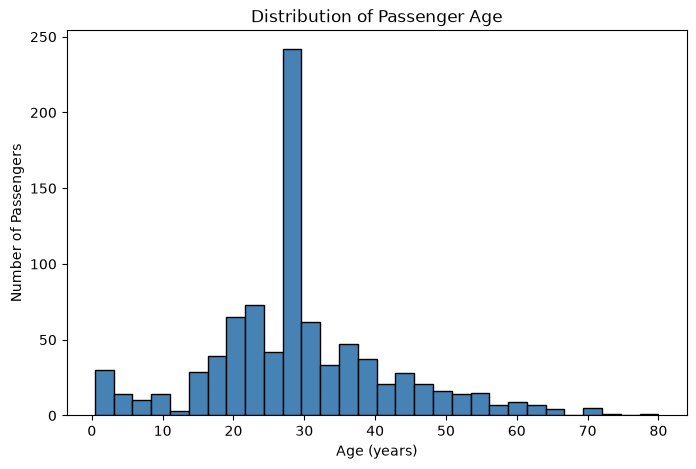

In [167]:
#16. Age: histogram
plt.figure(figsize=(8, 5))
plt.hist(df_clean["age"], bins=30, color="steelblue", edgecolor="black")
plt.title("Distribution of Passenger Age")
plt.xlabel("Age (years)")
plt.ylabel("Number of Passengers")
plt.show()

C:\Users\lenam\AppData\Local\Temp\ipykernel_16260\3387356737.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_clean["age"], vert=False)


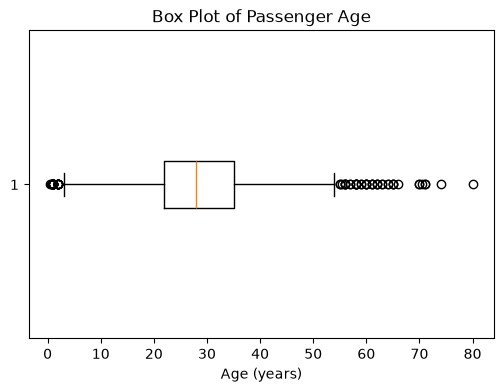

In [168]:
#17. Age: box plot
plt.figure(figsize=(6, 4))
plt.boxplot(df_clean["age"], vert=False)
plt.title("Box Plot of Passenger Age")
plt.xlabel("Age (years)")
plt.show()

In [169]:
#18. Age: IQR-based outlier count
Q1_age = df_clean["age"].quantile(0.25)
Q3_age = df_clean["age"].quantile(0.75)
IQR_age = Q3_age - Q1_age

lower_bound_age = Q1_age - 1.5 * IQR_age
upper_bound_age = Q3_age + 1.5 * IQR_age

age_outliers = df_clean[(df_clean["age"] < lower_bound_age) | (df_clean["age"] > upper_bound_age)]

print(f"Age Q1: {Q1_age}, Q3: {Q3_age}, IQR: {IQR_age}")
print(f"Lower bound: {lower_bound_age}, Upper bound: {upper_bound_age}")
print(f"Number of IQR-based outliers in age: {len(age_outliers)}")

Age Q1: 22.0, Q3: 35.0, IQR: 13.0
Lower bound: 2.5, Upper bound: 54.5
Number of IQR-based outliers in age: 65


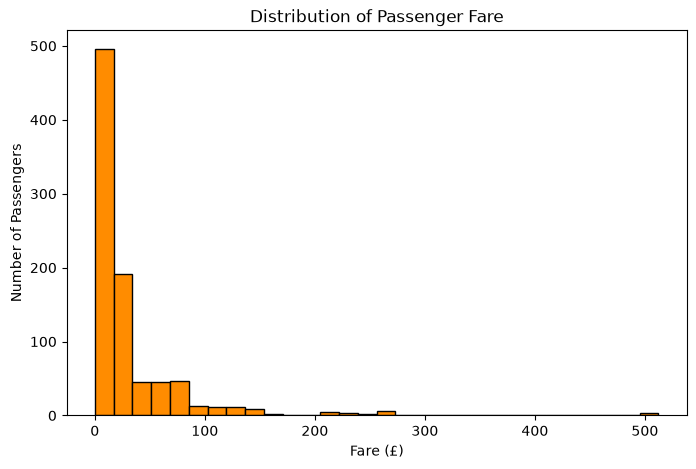

In [170]:
#19. Fare: histogram
plt.figure(figsize=(8, 5))
plt.hist(df_clean["fare"], bins=30, color="darkorange", edgecolor="black")
plt.title("Distribution of Passenger Fare")
plt.xlabel("Fare (£)")
plt.ylabel("Number of Passengers")
plt.show()

C:\Users\lenam\AppData\Local\Temp\ipykernel_16260\2192371754.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_clean["fare"], vert=False)


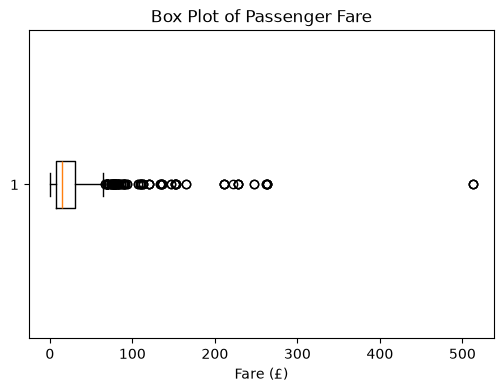

In [171]:
#20. Fare: box plot
plt.figure(figsize=(6, 4))
plt.boxplot(df_clean["fare"], vert=False)
plt.title("Box Plot of Passenger Fare")
plt.xlabel("Fare (£)")
plt.show()

In [172]:
#21. Fare: IQR-based outlier count
Q1_fare = df_clean["fare"].quantile(0.25)
Q3_fare = df_clean["fare"].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare

lower_bound_fare = Q1_fare - 1.5 * IQR_fare
upper_bound_fare = Q3_fare + 1.5 * IQR_fare

fare_outliers = df_clean[(df_clean["fare"] < lower_bound_fare) | (df_clean["fare"] > upper_bound_fare)]

print(f"Fare Q1: {Q1_fare}, Q3: {Q3_fare}, IQR: {IQR_fare}")
print(f"Lower bound: {lower_bound_fare}, Upper bound: {upper_bound_fare}")
print(f"Number of IQR-based outliers in fare: {len(fare_outliers)}")

Fare Q1: 7.8958, Q3: 31.0, IQR: 23.1042
Lower bound: -26.7605, Upper bound: 65.6563
Number of IQR-based outliers in fare: 114


In [173]:
#22. Fare: mean, median, mode, and skew determination
fare_mean = df_clean["fare"].mean()
fare_median = df_clean["fare"].median()
fare_mode = df_clean["fare"].mode()[0]  # mode() can return multiple values; take the first

print(f"Fare mean: {fare_mean}")
print(f"Fare median: {fare_median}")
print(f"Fare mode: {fare_mode}")

if fare_mean > fare_median > fare_mode:
    skew_direction = "right-skewed (long tail toward higher fares)"
elif fare_mean < fare_median < fare_mode:
    skew_direction = "left-skewed (long tail toward lower fares)"
else:
    skew_direction = "approximately symmetric (or does not follow the standard mean/median/mode ordering)"

print(f"\nFare distribution appears to be: {skew_direction}")

Fare mean: 32.09668087739032
Fare median: 14.4542
Fare mode: 8.05

Fare distribution appears to be: right-skewed (long tail toward higher fares)


## Part A.4

## Task 4 — Survival Rate Analysis (Boolean Masking)

In [174]:
#24. Survival rate by sex
female_survival_rate = df_clean[df_clean["sex"] == "female"]["survived"].mean()
male_survival_rate = df_clean[df_clean["sex"] == "male"]["survived"].mean()

print(f"Female survival rate: {female_survival_rate:.4f} ({female_survival_rate*100:.2f}%)")
print(f"Male survival rate: {male_survival_rate:.4f} ({male_survival_rate*100:.2f}%)")

Female survival rate: 0.7404 (74.04%)
Male survival rate: 0.1889 (18.89%)


In [175]:
#25. Survival rate by pclass
class1_survival_rate = df_clean[df_clean["pclass"] == 1]["survived"].mean()
class2_survival_rate = df_clean[df_clean["pclass"] == 2]["survived"].mean()
class3_survival_rate = df_clean[df_clean["pclass"] == 3]["survived"].mean()

print(f"Class 1 survival rate: {class1_survival_rate:.4f} ({class1_survival_rate*100:.2f}%)")
print(f"Class 2 survival rate: {class2_survival_rate:.4f} ({class2_survival_rate*100:.2f}%)")
print(f"Class 3 survival rate: {class3_survival_rate:.4f} ({class3_survival_rate*100:.2f}%)")

Class 1 survival rate: 0.6262 (62.62%)
Class 2 survival rate: 0.4728 (47.28%)
Class 3 survival rate: 0.2424 (24.24%)


In [176]:
#26. Survival rate by sex + pclass combined
combinations = [
    ("female", 1), ("female", 2), ("female", 3),
    ("male", 1), ("male", 2), ("male", 3),
]

print("Survival rate by sex and class combined:")
for sex_value, pclass_value in combinations:
    subset = df_clean[(df_clean["sex"] == sex_value) & (df_clean["pclass"] == pclass_value)]
    rate = subset["survived"].mean()
    count = len(subset)
    print(f"  {sex_value}, class {pclass_value}: {rate:.4f} ({rate*100:.2f}%)  [n={count}]")

Survival rate by sex and class combined:
  female, class 1: 0.9674 (96.74%)  [n=92]
  female, class 2: 0.9211 (92.11%)  [n=76]
  female, class 3: 0.5000 (50.00%)  [n=144]
  male, class 1: 0.3689 (36.89%)  [n=122]
  male, class 2: 0.1574 (15.74%)  [n=108]
  male, class 3: 0.1354 (13.54%)  [n=347]


## Part A.4

## Task 5 — Correlation Analysis

In [177]:
#28. Build the correlation matrix on the exact required columns
import seaborn as sns  # already imported earlier in the notebook, included here for clarity

correlation_columns = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
correlation_matrix = df_clean[correlation_columns].corr()

print(correlation_matrix) 

          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000


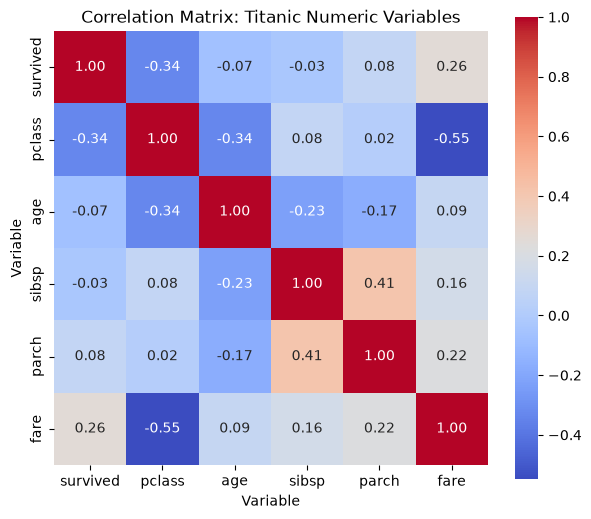

In [202]:
#29. Heatmap
plt.figure(figsize=(7, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix: Titanic Numeric Variables")
plt.xlabel("Variable")
plt.ylabel("Variable")
plt.savefig("charts/correlation_heatmap.png", dpi=150, bbox_inches="tight")   # ADD THIS LINE
plt.show()

In [179]:
#30. Identify and print the top 2 strongest pairs (excluding self-correlation)
# Turn the correlation matrix into a flat list of pairs, dropping self-pairs (correlation=1.0)
corr_pairs = correlation_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]

# Remove duplicate mirrored pairs (e.g. (age, fare) and (fare, age) are the same pair)
corr_pairs = corr_pairs.reset_index()
corr_pairs.columns = ["variable_1", "variable_2", "correlation"]
corr_pairs["pair_key"] = corr_pairs.apply(lambda row: tuple(sorted([row["variable_1"], row["variable_2"]])), axis=1)
corr_pairs = corr_pairs.drop_duplicates(subset="pair_key").drop(columns="pair_key")

# Sort by absolute correlation strength, strongest first
corr_pairs["abs_correlation"] = corr_pairs["correlation"].abs()
top_pairs = corr_pairs.sort_values("abs_correlation", ascending=False).head(2)

print("Top 2 strongest correlated pairs:")
print(top_pairs[["variable_1", "variable_2", "correlation"]])

Top 2 strongest correlated pairs:
   variable_1 variable_2  correlation
9      pclass       fare    -0.548193
18      sibsp      parch     0.414542


### Top 2 Correlated Pairs — Interpretation

**1. pclass and fare (r = -0.55):** The strongest correlation in the matrix. As passenger class number increases (moving from 1st to 3rd class), fare decreases sharply — which makes direct sense, since `pclass` is essentially a coded proxy for ticket price tier. This is expected by construction rather than a surprising discovery.

**2. sibsp and parch (r = 0.41):** The second-strongest correlation. Passengers travelling with more siblings/spouses (`sibsp`) also tend to be travelling with more parents/children (`parch`). This suggests family groups tended to travel together as a unit — a passenger with a larger `sibsp` count was often part of a larger family group overall, not travelling with just one type of relative in isolation.

## Part A.5
## Task 6 — Multivariate Data Story

### Chart 1: Survival Rate by Sex and Passenger Class

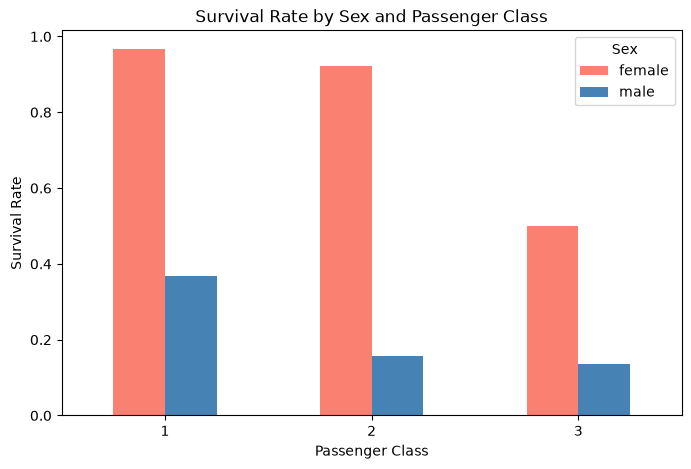

In [198]:
#34. 
survival_by_sex_class = df_clean.groupby(["pclass", "sex"])["survived"].mean().unstack()

survival_by_sex_class.plot(kind="bar", figsize=(8, 5), color=["salmon", "steelblue"])
plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.xticks(rotation=0)
plt.legend(title="Sex")
plt.savefig("charts/survival_by_sex_class.png", dpi=150, bbox_inches="tight")   # ADD THIS LINE
plt.show()

Female survival rate is dramatically higher than male at every passenger class, but the gap narrows in 3rd class: 1st class shows roughly 97% female vs 37% male survival, 2nd class shows roughly 92% vs 16%, while 3rd class drops to about 50% vs 14%. This shows that while sex was the single strongest survival factor across the board, class still meaningfully worsened outcomes for women specifically — 3rd class female survival was barely better than a coin flip, compared to near-certain survival in 1st class.

### Chart 2: Age Distribution by Survival Status

<Figure size 700x500 with 0 Axes>

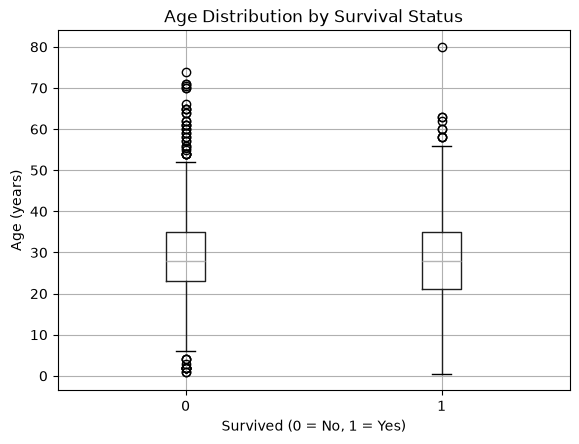

In [181]:
#37. 
plt.figure(figsize=(7, 5))
df_clean.boxplot(column="age", by="survived")
plt.title("Age Distribution by Survival Status")
plt.suptitle("")  # removes pandas' automatic default subtitle
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age (years)")
plt.show()

The two box plots are strikingly similar in overall shape and median age (both around 28), suggesting that age alone did not strongly separate survivors from non-survivors in this dataset. The non-survivor group (0) shows a noticeably lower minimum, including several very young children near age 0, and a slightly denser cluster of outliers in the 60-70 range, while the survivor group's most extreme outlier is a single 80-year-old. Overall, age by itself appears to be a much weaker predictor of survival than sex or class.

### Chart 3: Fare vs Age, Colored by Survival

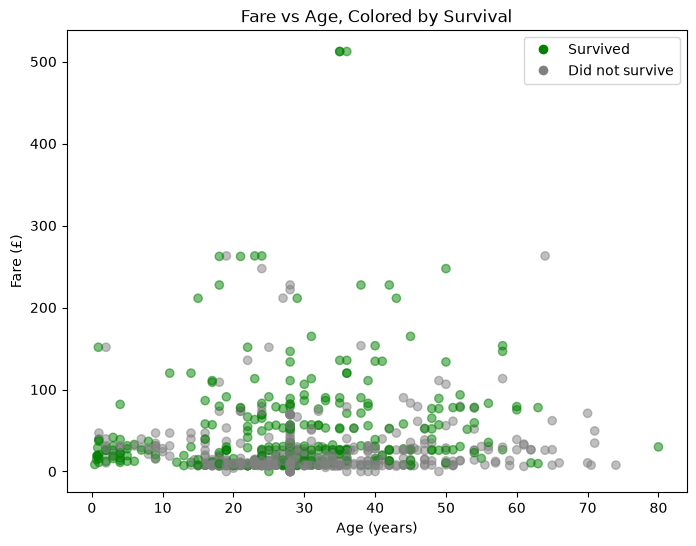

In [182]:
#40. 
plt.figure(figsize=(8, 6))
colors = df_clean["survived"].map({0: "grey", 1: "green"})
plt.scatter(df_clean["age"], df_clean["fare"], c=colors, alpha=0.5)
plt.title("Fare vs Age, Colored by Survival")
plt.xlabel("Age (years)")
plt.ylabel("Fare (£)")
plt.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='Survived'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='grey', markersize=8, label='Did not survive')
])
plt.show()

Green (survived) points are visibly denser at higher fare levels, especially above roughly £100, while grey (did not survive) points dominate the dense cluster of low fares below £50 — reinforcing that wealth/class strongly shaped survival odds at the individual level, not just in aggregate. Age shows no clear separating pattern by color across the x-axis; both outcomes are scattered fairly evenly across ages 0-80. The two highest-fare points (around £512) both survived, but this is only 2 passengers and should not be over-interpreted as a strong trend on its own.

### Chart 4: Survival Rate Heatmap — Class × Sex

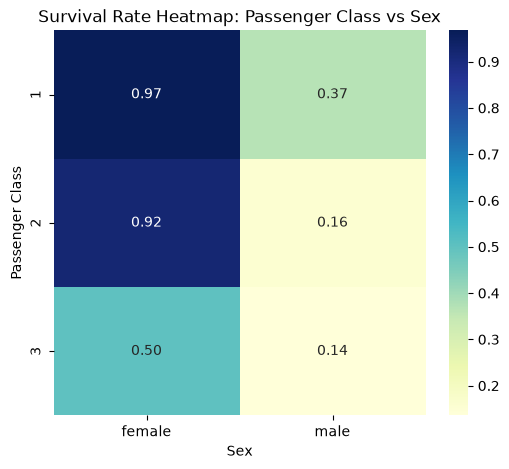

In [201]:
#43. 
plt.figure(figsize=(6, 5))
sns.heatmap(survival_by_sex_class, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Survival Rate Heatmap: Passenger Class vs Sex")
plt.xlabel("Sex")
plt.ylabel("Passenger Class")
plt.savefig("charts/survival_rate_heatmap.png", dpi=150, bbox_inches="tight")   # ADD THIS LINE
plt.show()

This heatmap numerically confirms Chart 1's bar chart: the highest survival rate is 1st class female at 0.97, and the lowest is 3rd class male at 0.14 — nearly a 7x difference between the best and worst combination. The clear visual split between the dark blue female column and the pale yellow/green male column reinforces that sex was the dominant factor, while the gradual darkening down each column from class 3 to class 1 shows class layered an additional, smaller effect on top of that.

## Part A.6

Task 7 — EDA-Stage Standardization Check (age and fare)

Note: this is an exploratory demonstration only. It is separate from, and not reused by, the actual preprocessing pipeline built later in `02_modeling.ipynb`, which will fit its own scaler on the training split only.

In [190]:
#46. Before: report original mean/std
print("BEFORE standardization:")
print(f"age  -> mean: {df_clean['age'].mean():.4f}, std: {df_clean['age'].std():.4f}")
print(f"fare -> mean: {df_clean['fare'].mean():.4f}, std: {df_clean['fare'].std():.4f}")

BEFORE standardization:
age  -> mean: 29.3152, std: 12.9849
fare -> mean: 32.0967, std: 49.6975


In [195]:
#47. Apply z-score standardization (exploratory copy only)
# z-score formula: (value - mean) / std
# Stored in NEW columns on a throwaway copy, so df_clean itself is untouched
df_standardized_check = df_clean.copy()

df_standardized_check["age_zscore"] = (
    (df_clean["age"] - df_clean["age"].mean()) / df_clean["age"].std()
)
df_standardized_check["fare_zscore"] = (
    (df_clean["fare"] - df_clean["fare"].mean()) / df_clean["fare"].std()
)

In [196]:
#48. After: report standardized mean/std

print("AFTER standardization:")
print(f"age_zscore  -> mean: {df_standardized_check['age_zscore'].mean():.4f}, std: {df_standardized_check['age_zscore'].std():.4f}")
print(f"fare_zscore -> mean: {df_standardized_check['fare_zscore'].mean():.4f}, std: {df_standardized_check['fare_zscore'].std():.4f}")

AFTER standardization:
age_zscore  -> mean: 0.0000, std: 1.0000
fare_zscore -> mean: 0.0000, std: 1.0000


In [194]:
#49. Confirm df_clean itself was never modified

print("df_clean columns (should NOT include age_zscore/fare_zscore):")
print(list(df_clean.columns))
print(f"\ndf_clean shape (should be unchanged): {df_clean.shape}")

df_clean columns (should NOT include age_zscore/fare_zscore):
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

df_clean shape (should be unchanged): (889, 15)
